In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import rc_context
import seaborn as sns
import json

# Find common genes

In [2]:
xenium_genes = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_84_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
xenium_genes = xenium_genes[1].tolist()
nanostring_genes = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\83005\83005_exprMat_file.csv.gz', sep=',')
nanostring_genes = nanostring_genes.columns.tolist()[2:1002]

In [3]:
common_genes = list(set(xenium_genes) & set(nanostring_genes))

In [4]:
len(common_genes)

260

# Common genes per cell

## Nanostring

### 83

In [56]:
expr_83 = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\83005\83005_exprMat_file.csv.gz', sep=',')
fov = expr_83['fov']
cell = expr_83['cell_ID']
expr_83 = expr_83[common_genes]

In [57]:
total_83 = expr_83.sum(axis=1)
log_total_83 = np.log10(total_83 + 1)

In [58]:
cell_83 = 'c_1_' + fov.astype(str) + '_' + cell.astype(str)
cell_83 = cell_83.tolist()
cellData_83 = pd.DataFrame({'cell_id': cell_83, 'total': total_83, 'log_total': log_total_83})

In [59]:
metadata_83 = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\83005\83005_metadata_file.csv.gz', sep=',')

In [60]:
metadata_83 = metadata_83[['cell_id', 'CenterX_global_px', 'CenterY_global_px']]

In [62]:
data_83 = pd.merge(cellData_83, metadata_83, on='cell_id')
data_83['CenterX_global_px'] = -data_83['CenterX_global_px']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


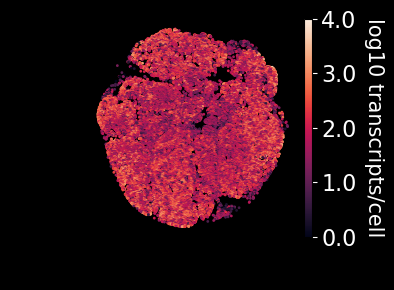

In [154]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(x='CenterX_global_px', y='CenterY_global_px', hue='log_total', data=data_83, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\83 log transcript per cell.png', dpi=300)
    plt.show()

### 84

In [113]:
expr_84 = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\84005\84005_exprMat_file.csv.gz', sep=',')
fov = expr_84['fov']
cell = expr_84['cell_ID']
expr_84 = expr_84[common_genes]

total_84 = expr_84.sum(axis=1)
log_total_84 = np.log10(total_84 + 1)

cell_84 = 'c_2_' + fov.astype(str) + '_' + cell.astype(str)
cell_84 = cell_84.tolist()
cellData_84 = pd.DataFrame({'cell_id': cell_84, 'total': total_84, 'log_total': log_total_84})

In [119]:
metadata_84 = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\84005\84005_metadata_file.csv.gz', sep=',')
metadata_84 = metadata_84[['cell_id', 'CenterX_global_px', 'CenterY_global_px']]

In [120]:
data_84 = pd.merge(cellData_84, metadata_84, on='cell_id')
data_84['CenterX_global_px'] = -data_84['CenterX_global_px']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


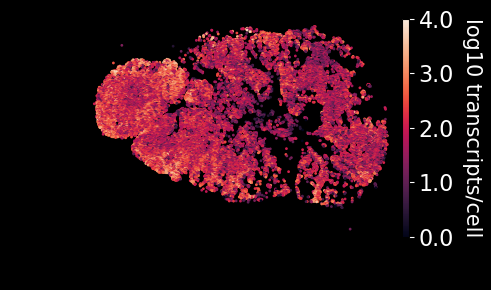

In [150]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.scatterplot(x='CenterX_global_px', y='CenterY_global_px', hue='log_total', data=data_84, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\84 log transcript per cell.png', dpi=300)
    plt.show()

### 7202

In [23]:
expr_7202 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\7202_2\7202_2_exprMat_file.csv.gz', sep=',')
fov = expr_7202['fov']
cell = expr_7202['cell_ID']
expr_7202 = expr_7202[common_genes]

total_7202 = expr_7202.sum(axis=1)
log_total_7202 = np.log10(total_7202 + 1)

cell_7202 = 'c_1_' + fov.astype(str) + '_' + cell.astype(str)
cell_7202 = cell_7202.tolist()
cellData_7202 = pd.DataFrame({'cell_id': cell_7202, 'total': total_7202, 'log_total': log_total_7202})

In [24]:
metadata_7202 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\7202_2\7202_2_metadata_file.csv.gz', sep=',')
metadata_7202 = metadata_7202[['cell_id', 'CenterX_global_px', 'CenterY_global_px']]

In [25]:
data_7202 = pd.merge(cellData_7202, metadata_7202, on='cell_id')
data_7202['CenterX_global_px'] = -data_7202['CenterX_global_px']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


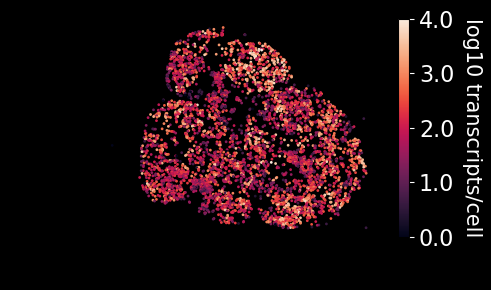

In [26]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.scatterplot(x='CenterX_global_px', y='CenterY_global_px', hue='log_total', data=data_7202, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=20)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\7202 log transcript per cell.png', dpi=300)
    plt.show()

### 174

In [32]:
expr_174 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\174_2\174_2_exprMat_file.csv.gz', sep=',')
fov = expr_174['fov']
cell = expr_174['cell_ID']
expr_174 = expr_174[common_genes]

total_174 = expr_174.sum(axis=1)
log_total_174 = np.log10(total_174 + 1)

cell_174 = 'c_1_' + fov.astype(str) + '_' + cell.astype(str)
cell_174 = cell_174.tolist()
cellData_174 = pd.DataFrame({'cell_id': cell_174, 'total': total_174, 'log_total': log_total_174})

In [11]:
metadata_174 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\174_2\174_2_metadata_file.csv.gz', sep=',')
metadata_174 = metadata_174[['cell_id', 'CenterX_global_px', 'CenterY_global_px']]

In [12]:
metadata_174

,cell_id,CenterX_global_px,CenterY_global_px
0,c_1_19_8,3868.000000,10661.999843
1,c_1_19_9,4211.000000,10653.999843
2,c_1_19_10,3868.000000,10578.999843
3,c_1_19_11,3618.000000,10577.999843
4,c_1_19_12,3452.000000,10501.999843
...,...,...,...
4591,c_1_33_130,9474.999895,-1930.000000
4592,c_1_33_131,9252.999895,-1952.000000
4593,c_1_33_132,9004.999895,-2045.000000
4594,c_1_33_133,8957.999895,-2106.000000


In [34]:
data_174 = pd.merge(cellData_174, metadata_174, on='cell_id')
data_174['CenterX_global_px'] = -data_174['CenterX_global_px']

In [36]:
data_174.shape

(4596, 5)

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


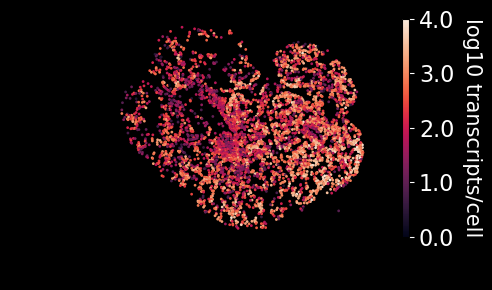

In [35]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.scatterplot(x='CenterX_global_px', y='CenterY_global_px', hue='log_total', data=data_174, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\174 log transcript per cell.png', dpi=300)
    plt.show()

## Xenium

In [40]:
from scipy import io
import gzip

## 83

In [169]:
cell_83 = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cells.csv.gz')
cell_83 = cell_83[['cell_id','x_centroid','y_centroid']]

In [190]:
with gzip.open(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
    mtx = io.mmread(f)
features = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
barcodes = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_83_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

In [200]:
# convert to dense matrix
# mtx = mtx.todense()
xenium_expr_83 = pd.DataFrame(mtx.T, columns=features[1].tolist())

In [201]:
xenium_expr_83 = xenium_expr_83[common_genes]

In [206]:
sum_83 = xenium_expr_83.sum(axis=1)
log_83 = np.log10(sum_83 + 1)
xenium_total_83 = pd.DataFrame({'barcodes': barcodes[0].tolist(), 'total': sum_83, 'log_total': log_83})

In [208]:
cell_83

,cell_id,x_centroid,y_centroid
0,aaaaabbe-1,937.904602,822.977783
1,aaabgcmd-1,940.671204,888.302002
2,aaadbide-1,928.088196,845.257446
3,aaaffdlm-1,934.213135,816.328796
4,aaagbkbm-1,956.260803,889.810486
...,...,...,...
71843,ojbemmfa-1,1147.772705,3110.843506
71844,ojbfamfi-1,1015.035217,3120.465332
71845,ojbgnaeb-1,866.504211,3135.776367
71846,ojbhllal-1,875.292419,3033.112549


In [209]:
xenium_data_83 = pd.merge(xenium_total_83, cell_83, left_on='barcodes', right_on='cell_id')

In [213]:
xenium_data_83['y_centroid'] = -xenium_data_83['y_centroid']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


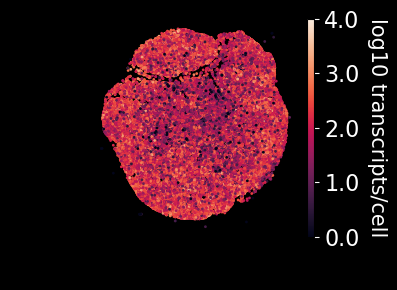

In [214]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.scatterplot(x='x_centroid', y='y_centroid', hue='log_total', data=xenium_data_83, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\83 log transcript per cell xenium.png', dpi=300)
    plt.show()

## 84

In [215]:
cell_84 = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_84_a\cells.csv.gz')
cell_84 = cell_84[['cell_id','x_centroid','y_centroid']]

In [218]:
with gzip.open(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_84_a\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
    mtx = io.mmread(f)
features = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_84_a\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
barcodes = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_84_a\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

In [219]:
mtx = mtx.todense()
xenium_expr_84 = pd.DataFrame(mtx.T, columns=features[1].tolist())
xenium_expr_84 = xenium_expr_84[common_genes]

sum_84 = xenium_expr_84.sum(axis=1)
log_84 = np.log10(sum_84 + 1)
xenium_total_84 = pd.DataFrame({'barcodes': barcodes[0].tolist(), 'total': sum_84, 'log_total': log_84})

In [220]:
xenium_data_84 = pd.merge(xenium_total_84, cell_84, left_on='barcodes', right_on='cell_id')
xenium_data_84['y_centroid'] = -xenium_data_84['y_centroid']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


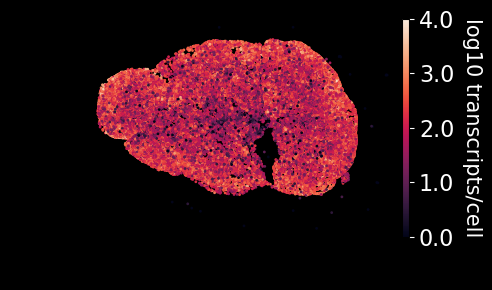

In [222]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.scatterplot(x='x_centroid', y='y_centroid', hue='log_total', data=xenium_data_84, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\84 log transcript per cell xenium.png', dpi=300)
    plt.show()

## 7202

In [228]:
cell_7202 = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_7202_c\cells.csv.gz')
cell_7202 = cell_7202[['cell_id','x_centroid','y_centroid']]

In [229]:
with gzip.open(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_7202_c\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
    mtx = io.mmread(f)
features = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_7202_c\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
barcodes = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029745_7202_c\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

In [230]:
mtx = mtx.todense()
xenium_expr_7202 = pd.DataFrame(mtx.T, columns=features[1].tolist())
xenium_expr_7202 = xenium_expr_7202[common_genes]

sum_7202 = xenium_expr_7202.sum(axis=1)
log_7202 = np.log10(sum_7202 + 1)
xenium_total_7202 = pd.DataFrame({'barcodes': barcodes[0].tolist(), 'total': sum_7202, 'log_total': log_7202})

In [231]:
xenium_data_7202 = pd.merge(xenium_total_7202, cell_7202, left_on='barcodes', right_on='cell_id')
xenium_data_7202['y_centroid'] = -xenium_data_7202['y_centroid']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


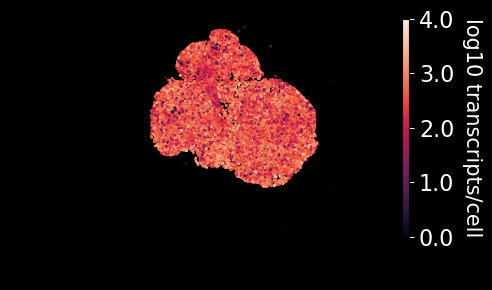

In [235]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.scatterplot(x='x_centroid', y='y_centroid', hue='log_total', data=xenium_data_7202, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\7202 log transcript per cell xenium.png', dpi=300)
    plt.show()

## 174

In [236]:
cell_174 = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cells.csv.gz')
cell_174 = cell_174[['cell_id','x_centroid','y_centroid']]

In [237]:
with gzip.open(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\matrix.mtx.gz', 'rb') as f:
    mtx = io.mmread(f)
features = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\features.tsv.gz', sep='\t', header=None)
barcodes = pd.read_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\0029866_174_c\cell_feature_matrix\barcodes.tsv.gz', sep='\t', header=None)

In [238]:
mtx = mtx.todense()
xenium_expr_174 = pd.DataFrame(mtx.T, columns=features[1].tolist())
xenium_expr_174 = xenium_expr_174[common_genes]

sum_174 = xenium_expr_174.sum(axis=1)
log_174 = np.log10(sum_174 + 1)
xenium_total_174 = pd.DataFrame({'barcodes': barcodes[0].tolist(), 'total': sum_174, 'log_total': log_174})

In [239]:
xenium_data_174 = pd.merge(xenium_total_174, cell_174, left_on='barcodes', right_on='cell_id')
xenium_data_174['y_centroid'] = -xenium_data_174['y_centroid']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\seaborn\relational.py:573: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


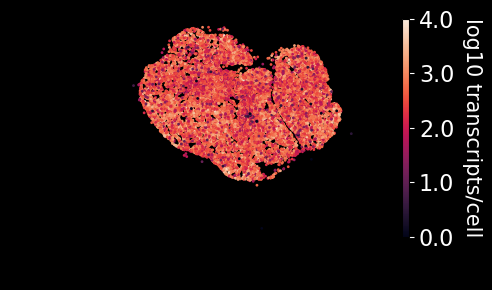

In [240]:
with rc_context({'figure.facecolor': 'black', 'axes.facecolor': 'black', 'savefig.facecolor': 'black', 'text.color': 'white'}):
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.scatterplot(x='x_centroid', y='y_centroid', hue='log_total', data=xenium_data_174, ax=ax, vmin=0, vmax=4, palette='rocket', s=4, edgecolor='none')
    ax.axis('equal')
    ax.legend([], [], frameon=False)
    # add colorbar, show the scale
    sm = plt.cm.ScalarMappable(cmap='rocket', norm=plt.Normalize(vmin=0, vmax=4))
    cbar = plt.colorbar(sm, ax=ax, pad=0.01, aspect=30)
    cbar.ax.yaxis.set_tick_params(color='white')
    cbar.set_ticks([0.0, 1.0, 2.0, 3.0, 4.0])
    cbar.set_ticklabels(['0.0', '1.0', '2.0', '3.0', '4.0'], color='white', fontsize=16)
    cbar.set_label('log10 transcripts/cell', color='white', fontsize=15, rotation=270, labelpad=20)
    plt.tight_layout()
    plt.savefig(r'..\figures\174 log transcript per cell xenium.png', dpi=300)
    plt.show()

# batch normalization

In [14]:
import scanorama
from tqdm import tqdm
import scanpy as sc
import os

In [170]:
xenium_cells = []
xenium_samples = []
xenium_data = []
xenium_genes = []
for fn in tqdm(fn_l):
    if 'HnE' in fn:
        continue
    if os.path.isdir(os.path.join(in_dir,fn,'cell_feature_matrix')) == False:
        continue
    else:
        with gzip.open(os.path.join(in_dir,fn,'cell_feature_matrix','matrix.mtx.gz'), 'rb') as f:
            mtx = io.mmread(f)
        mtx = mtx.todense().T
        mtx = mtx[:,:480]
        features = pd.read_csv(os.path.join(in_dir,fn,'cell_feature_matrix','features.tsv.gz'), sep='\t', header=None)
        barcodes = pd.read_csv(os.path.join(in_dir,fn,'cell_feature_matrix','barcodes.tsv.gz'), sep='\t', header=None)

        temp = fn.split('_')
        sample = temp[1] + '_' + temp[2]
        xenium_data.append(mtx)
        xenium_cells.append((sample + '_' + barcodes[0]).tolist())
        xenium_genes.append(features[1].tolist()[:480])
        
        xenium_samples.append([sample] * mtx.shape[0])

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:20<00:00,  1.88s/it]


In [256]:
integrated, corrected, genes = scanorama.correct(xenium_data, xenium_genes, return_dimred=True)

Found 480 genes among all datasets
[[0.         0.65596689 0.20915153 0.14748218 0.3131519  0.28846737
  0.19282594 0.17176362]
 [0.         0.         0.23968986 0.15468772 0.34983815 0.31513242
  0.21695286 0.18850782]
 [0.         0.         0.         0.65127725 0.23258602 0.19713957
  0.34686413 0.31412258]
 [0.         0.         0.         0.         0.28743556 0.23180413
  0.42798073 0.38879585]
 [0.         0.         0.         0.         0.         0.49960608
  0.34036686 0.29756624]
 [0.         0.         0.         0.         0.         0.
  0.39664263 0.34603963]
 [0.         0.         0.         0.         0.         0.
  0.         0.62212822]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]
Processing datasets (0, 1)
Processing datasets (2, 3)
Processing datasets (6, 7)
Processing datasets (4, 5)
Processing datasets (3, 6)
Processing datasets (5, 6)
Processing datasets (3, 7)
Processing datasets (1, 4)
Processing datasets (2, 6)
P

In [280]:
corrected_full = []
for i in range(len(corrected)):
    corrected_full.append(np.array(corrected[i].todense()))
X = np.concatenate(corrected_full, axis=0)

In [281]:
adata = sc.AnnData(X)
adata.obs_names = [item for sublist in cells for item in sublist]
adata.var_names = genes
adata.obs['sample'] = [item for sublist in samples for item in sublist]

In [283]:
sc.tl.rank_genes_groups(adata, 'sample')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encounter

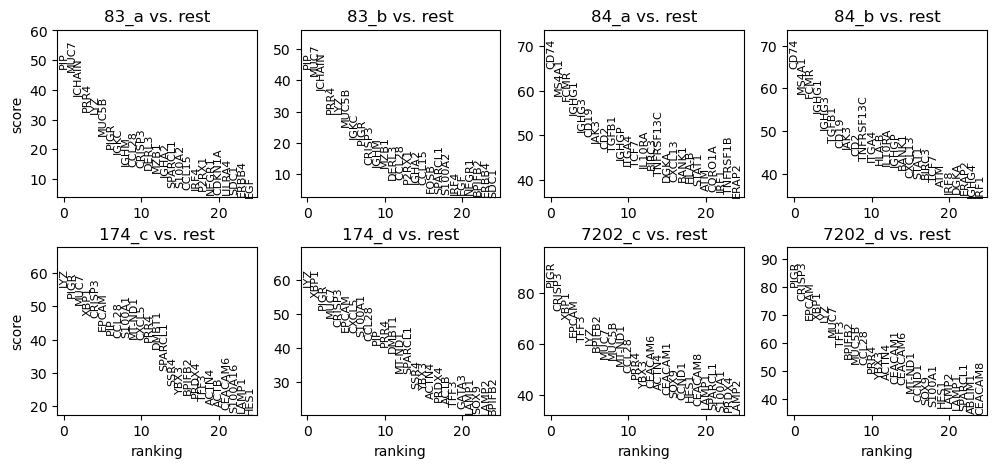

In [291]:
with rc_context({'figure.figsize':(3,2.5)}):
    sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, ncols=4, save=' by samples.png')

In [295]:
ssa = [''] * adata.X.shape[0]
for i in range(len(corrected)):
    if '83_' in adata.obs['sample'][i] or '84_' in adata.obs['sample'][i]:
        ssa[i] = 'SSA+'
    else:
        ssa[i] = 'SSA-'

adata.obs['SSA'] = ssa

In [296]:
sc.tl.rank_genes_groups(adata, 'SSA')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


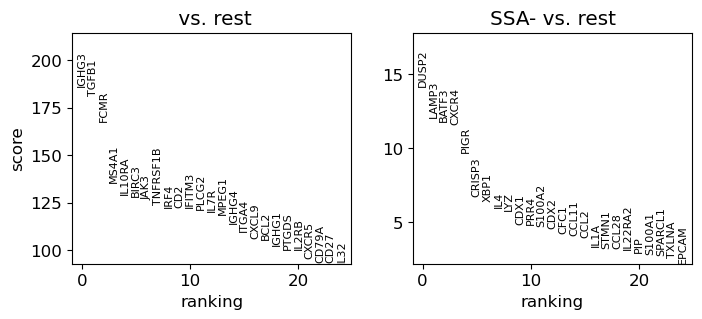

In [300]:
with rc_context({'figure.figsize':(4,3), 'font.size': 12}):
    sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, ncols=2, save=' by SSA.png')

In [302]:
adata.write_h5ad(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected.h5ad')

In [3]:
adata = sc.read_h5ad(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected.h5ad')

c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy\lib\site-packages\anndata\_core\anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
df = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
df['sample'] = adata.obs['sample']

In [5]:
df

,A2M,ABL1,ABLIM1,ACE2,ACTA2,ACTB,ACTN1,ACTN4,ADAM28,AEBP1,...,VCAN,VEGFA,VSIG4,VSIR,XBP1,XIST,YBX3,ZFHX3,ZNF683,sample
aaaehcah-1,-0.001364,-0.002697,-0.007136,-0.000144,0.004392,0.052689,0.044721,0.049961,-0.000511,-0.000725,...,0.000439,-0.007878,0.000728,7.310027e-07,0.157597,-0.008872,0.017502,0.000411,0.000246,7202_c
aaagbhce-1,-0.000924,-0.002789,-0.005836,-0.000213,-0.005325,0.038489,0.001018,-0.002075,-0.000359,-0.000724,...,0.000531,-0.007467,0.039422,5.653440e-05,0.186450,-0.008765,-0.012829,0.000040,0.000287,7202_c
aaaggmkl-1,0.060018,-0.001504,0.056112,-0.000217,-0.003825,0.003096,0.060358,-0.002936,-0.000708,-0.000452,...,0.000353,-0.006590,0.000589,-3.634754e-04,0.124216,-0.004589,0.046578,0.000046,-0.000037,7202_c
aaahafkn-1,-0.002092,-0.002674,0.008605,-0.000345,0.021696,0.052901,0.013384,0.009888,-0.000384,-0.000994,...,0.000529,-0.008066,0.000730,5.245689e-04,0.216896,0.005082,0.025887,0.000040,0.000381,7202_c
aaaoippf-1,-0.000170,-0.000143,0.011209,-0.000262,-0.003538,0.012901,0.015204,-0.004525,0.001042,0.000570,...,0.000557,-0.000623,0.000184,-1.732250e-04,0.192338,0.003887,0.015712,-0.001279,-0.000046,7202_c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oiildlmm-1,-0.001392,0.050321,0.004955,-0.001270,0.005762,-0.001507,-0.000265,-0.001982,-0.005903,0.005103,...,0.004358,0.001898,0.000303,4.611086e-03,0.012435,0.048132,0.001422,-0.000589,-0.000352,83_b
oiilgleh-1,-0.016087,-0.000489,-0.002142,-0.001064,-0.004540,0.002042,-0.003603,0.023290,-0.002968,0.017026,...,-0.021829,-0.001009,0.000826,-1.462380e-02,0.019499,-0.012373,0.001030,0.018401,0.000216,83_b
oiilkiif-1,-0.007759,0.000637,-0.003491,-0.000581,-0.006056,0.015669,0.000971,-0.006590,0.004469,0.048787,...,-0.010555,-0.001047,-0.007221,-1.272094e-02,0.013447,0.007778,-0.000214,0.006084,0.001354,83_b
oiingpaf-1,-0.110116,-0.000174,-0.022738,-0.000740,-0.011096,0.033247,-0.000207,0.052382,0.054987,-0.013962,...,0.010515,0.001368,-0.028819,-2.639956e-02,0.020305,0.074029,0.048010,-0.020975,-0.000655,83_b


In [6]:
df[df['sample'] == '83_a'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_83a.csv')
df[df['sample'] == '83_b'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_83b.csv')
df[df['sample'] == '84_a'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_84a.csv')
df[df['sample'] == '84_b'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_84b.csv')
df[df['sample'] == '174_c'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_174c.csv')
df[df['sample'] == '174_d'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_174d.csv')
df[df['sample'] == '7202_c'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_7202c.csv')
df[df['sample'] == '7202_d'].to_csv(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected_7202d.csv')

In [304]:
integrated_full = []
for i in range(len(integrated)):
    integrated_full.append(np.array(integrated[i]))
X_integrated = np.concatenate(integrated_full, axis=0)

In [306]:
integrated[0].shape

(21745, 100)

In [307]:
integrated_adata = sc.AnnData(X_integrated)
integrated_adata.obs_names = [item for sublist in cells for item in sublist]
# integrated_adata.var_names = genes
integrated_adata.obs['sample'] = [item for sublist in samples for item in sublist]

In [308]:
integrated_adata.write_h5ad(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\integrated.h5ad')

# xenium, nanostring integration

In [11]:
nanostring_data = []
nanostring_cells = []
nanostring_genes = []

nanostring_83 = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\83005\83005_exprMat_file.csv.gz', sep=',')
nanostring_data.append(nanostring_83.values[:,2:1002])
nanostring_genes.append(nanostring_83.columns[2:1002])
nanostring_cells += ('c_1_' + nanostring_83['fov'].astype(str) + '_' + nanostring_83['cell_ID'].astype(str)).tolist()
metadata = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\83005\83005_metadata_file.csv.gz', sep=',')
nanostring_83_cells = metadata['cell'].tolist()

nanostring_84 = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\84005\84005_exprMat_file.csv.gz', sep=',')
nanostring_data.append(nanostring_84.values[:,2:1002])
nanostring_genes.append(nanostring_84.columns[2:1002])
nanostring_cells += ('c_2_' + nanostring_84['fov'].astype(str) + '_' + nanostring_84['cell_ID'].astype(str)).tolist()
metadata = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\84005\84005_metadata_file.csv.gz', sep=',')
nanostring_84_cells = metadata['cell'].tolist()

nanostring_72021 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\7202_1\7202_1_exprMat_file.csv.gz', sep=',')
nanostring_data.append(nanostring_72021.values[:,2:1002])
nanostring_genes.append(nanostring_72021.columns[2:1002])
nanostring_cells += ('rerun1_c_1_' + nanostring_72021['fov'].astype(str) + '_' + nanostring_72021['cell_ID'].astype(str)).tolist()
metadata = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\7202_1\7202_1_metadata_file.csv.gz', sep=',')
nanostring_72021_cells = metadata['cell'].tolist()

nanostring_72022 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\7202_2\7202_2_exprMat_file.csv.gz', sep=',')
nanostring_data.append(nanostring_72022.values[:,2:1002])
nanostring_genes.append(nanostring_72022.columns[2:1002])
nanostring_cells += ('rerun2_c_1_' + nanostring_72022['fov'].astype(str) + '_' + nanostring_72022['cell_ID'].astype(str)).tolist()
metadata = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\7202_2\7202_2_metadata_file.csv.gz', sep=',')
nanostring_72022_cells = metadata['cell'].tolist()

nanostring_1741 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\174_1\174_1_exprMat_file.csv.gz', sep=',')
nanostring_data.append(nanostring_1741.values[:,2:1002])
nanostring_genes.append(nanostring_1741.columns[2:1002])
nanostring_cells += ('rerun1_c_1_' + nanostring_1741['fov'].astype(str) + '_' + nanostring_1741['cell_ID'].astype(str)).tolist()
metadata = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\174_1\174_1_metadata_file.csv.gz', sep=',')
nanostring_1741_cells = metadata['cell'].tolist()

nanostring_1742 = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\174_2\174_2_exprMat_file.csv.gz', sep=',')
nanostring_data.append(nanostring_1742.values[:,2:1002])
nanostring_genes.append(nanostring_1742.columns[2:1002])
nanostring_cells += ('rerun2_c_1_' + nanostring_1742['fov'].astype(str) + '_' + nanostring_1742['cell_ID'].astype(str)).tolist()
metadata = pd.read_csv(r'..\..\20240827_cosmx\GATech_Ahmet_2nd\174-7202_1\Flat_File\174_2\174_2_metadata_file.csv.gz', sep=',')
nanostring_1742_cells = metadata['cell'].tolist()

In [173]:
integrated, corrected, genes = scanorama.correct(xenium_data+nanostring_data, xenium_genes+nanostring_genes, return_dimred=True)

Found 260 genes among all datasets
[[0.         0.60832375 0.23936537 0.17604047 0.31117372 0.29622447
  0.23954932 0.20561049 0.00726604 0.00395493 0.02227987 0.02034884
  0.00518719 0.00478677]
 [0.         0.         0.26128526 0.19202778 0.33958758 0.31695049
  0.26537602 0.23108025 0.00727774 0.00261618 0.01953304 0.0181127
  0.0045106  0.0089208 ]
 [0.         0.         0.         0.57831504 0.23852056 0.19986667
  0.32076902 0.28108365 0.09200482 0.10246341 0.10773691 0.11247764
  0.05480379 0.05961706]
 [0.         0.         0.         0.         0.27167006 0.23416763
  0.37210819 0.3298555  0.1064082  0.12401415 0.13230581 0.12790698
  0.06044204 0.07267189]
 [0.         0.         0.         0.         0.         0.44433671
  0.34486273 0.30176238 0.01240858 0.00653399 0.01297116 0.01498211
  0.00789355 0.01109661]
 [0.         0.         0.         0.         0.         0.
  0.39785468 0.34937277 0.01290831 0.00709048 0.01724401 0.01453488
  0.00699143 0.01066144]
 [0.    

In [3]:
import pickle

In [175]:
with open(r'..\results\v3\nanostring_xenium_integrated.pkl', 'wb') as f:
    pickle.dump({'integrated': integrated, 'corrected': corrected, 'genes': genes}, f)

In [176]:
# integrated_data = pd.read_pickle(r'..\results\v2\nanostring_xenium_integrated.pkl')

In [177]:
integrated_adata = sc.AnnData(np.concatenate(integrated, axis=0))

In [178]:
sc.pp.normalize_total(integrated_adata)

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\preprocessing\_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


In [179]:
sc.pp.neighbors(integrated_adata, n_neighbors=30)

         Falling back to preprocessing with `sc.pp.pca` and default params.


c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\anndata\_core\anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [180]:
sc.tl.umap(integrated_adata)
sc.tl.tsne(integrated_adata)

In [5]:
integrated_adata = sc.read_h5ad(r'..\results\v2\nanostring_xenium_integrated.h5ad')

c:\Users\zfang38\AppData\Local\anaconda3\envs\scanpy2\lib\site-packages\anndata\_core\anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
integrated_adata

AnnData object with n_obs × n_vars = 455516 × 100
    obs: 'sample', 'condition', 'experiment', 'nanostring_cluster', 'CoxMx_cluster', 'CosMx_cluster'
    uns: 'CosMx_cluster_colors', 'condition_colors', 'experiment_colors', 'nanostring_cluster_colors', 'neighbors', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

In [205]:
samples = []
for i in range(len(xenium_samples)):
    samples += xenium_samples[i]
samples += ['83']*nanostring_data[0].shape[0]
samples += ['84']*nanostring_data[1].shape[0]
samples += ['7202_1']*nanostring_data[2].shape[0]
samples += ['7202_2']*nanostring_data[3].shape[0]
samples += ['174_1']*nanostring_data[4].shape[0]
samples += ['174_2']*nanostring_data[5].shape[0]

integrated_adata.obs['sample'] = samples

In [182]:
conditions = [''] * integrated_adata.X.shape[0]
for i in range(integrated_adata.X.shape[0]):
    if '83' in integrated_adata.obs['sample'][i] or '84' in integrated_adata.obs['sample'][i]:
        conditions[i] = 'SSA+'
    else:
        conditions[i] = 'SSA-'
integrated_adata.obs['condition'] = conditions

In [183]:
experiment = []
for item in xenium_data:
    experiment += ['Xenium'] * item.shape[0]
for item in nanostring_data:
    experiment += ['CosMx'] * item.shape[0]
integrated_adata.obs['experiment'] = experiment

In [184]:
cells = []
for i in range(len(xenium_cells)):
    cells += xenium_cells[i]
cells += nanostring_cells
integrated_adata.obs_names = cells

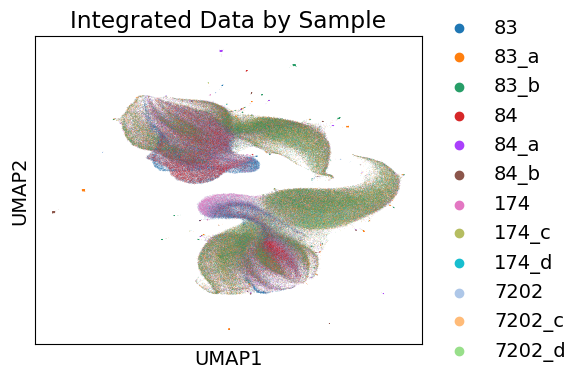

In [20]:
with rc_context({'figure.figsize':(5,4), 'font.size': 14}):
    sc.pl.umap(integrated_adata, color='sample', title='Integrated Data by Sample', save=' v3 by sample.png')

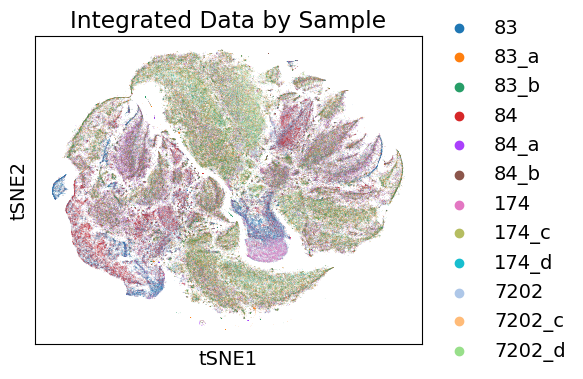

In [14]:
with rc_context({'figure.figsize':(5,4), 'font.size': 14}):
    sc.pl.tsne(integrated_adata, color='sample', title='Integrated Data by Sample', save=' v3 by sample.png')

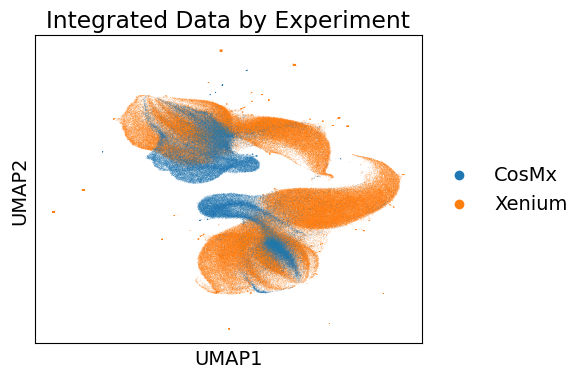

In [15]:
with rc_context({'figure.figsize':(5,4), 'font.size': 14}):
    sc.pl.umap(integrated_adata, color='experiment', title='Integrated Data by Experiment', save=' v3 by experiment.png')

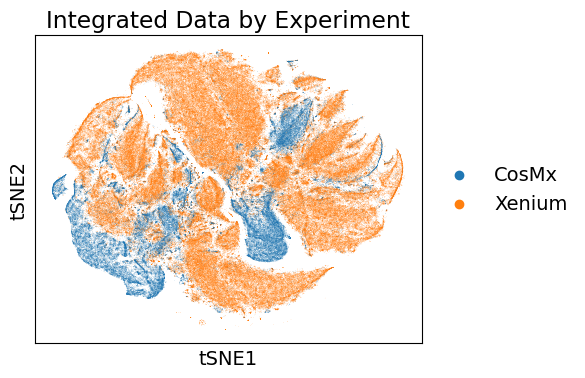

In [16]:
with rc_context({'figure.figsize':(5,4), 'font.size': 14}):
    sc.pl.tsne(integrated_adata, color='experiment', title='Integrated Data by Experiment', save=' v3 by experiment.png')

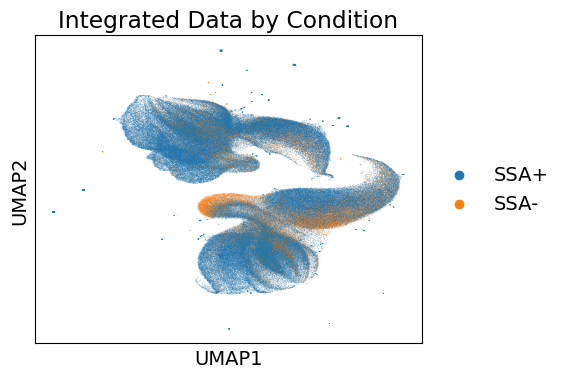

In [18]:
with rc_context({'figure.figsize':(5,4), 'font.size': 14}):
    sc.pl.umap(integrated_adata, color='condition', title='Integrated Data by Condition', save=' v3 by condition.png')

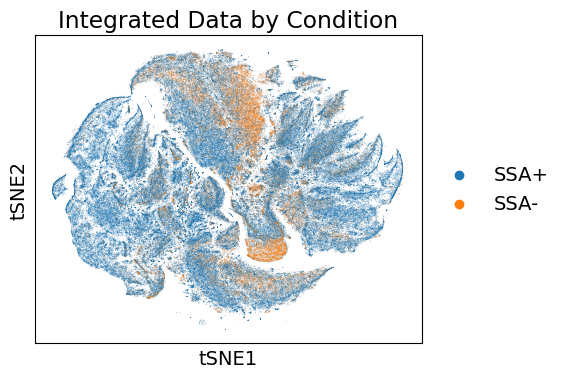

In [19]:
with rc_context({'figure.figsize':(5,4), 'font.size': 14}):
    sc.pl.tsne(integrated_adata, color='condition', title='Integrated Data by Condition', save=' v3 by condition.png')

In [207]:
integrated_adata.write_h5ad(r'..\results\v3\nanostring_xenium_integrated.h5ad')

## CosMx batch correction

In [15]:
integrated, corrected, genes = scanorama.correct(nanostring_data, nanostring_genes, return_dimred=True)

Found 1000 genes among all datasets
[[0.         0.59595599 0.49900809 0.31149374 0.3105548  0.25413403]
 [0.         0.         0.41141462 0.28331843 0.20884078 0.22106179]
 [0.         0.         0.         0.57848837 0.43820478 0.25761532]
 [0.         0.         0.         0.         0.42241768 0.29584079]
 [0.         0.         0.         0.         0.         0.55051872]
 [0.         0.         0.         0.         0.         0.        ]]
Processing datasets (0, 1)
Processing datasets (2, 3)
Processing datasets (4, 5)
Processing datasets (0, 2)
Processing datasets (2, 4)
Processing datasets (3, 4)
Processing datasets (1, 2)
Processing datasets (0, 3)
Processing datasets (0, 4)
Processing datasets (3, 5)
Processing datasets (1, 3)
Processing datasets (2, 5)
Processing datasets (0, 5)
Processing datasets (1, 5)
Processing datasets (1, 4)


In [32]:
for i in range(len(corrected)):
    corrected[i] = corrected[i].todense()

In [33]:
type(corrected[i])

numpy.matrix

In [42]:
cosmx_x = np.concatenate(corrected, axis=0)
cosmx_adata = sc.AnnData(np.asarray(cosmx_x))
cosmx_adata.obs_names = nanostring_83_cells + nanostring_84_cells + nanostring_72021_cells + nanostring_72022_cells + nanostring_1741_cells + nanostring_1742_cells
cosmx_adata.var_names = nanostring_genes[0]
cosmx_adata.obs['sample'] = ['83']*nanostring_data[0].shape[0] + ['84']*nanostring_data[1].shape[0] + ['7202-1']*nanostring_data[2].shape[0] + ['7202-2']*nanostring_data[3].shape[0] + ['174-1']*nanostring_data[4].shape[0] + ['174-2']*nanostring_data[5].shape[0]

In [43]:
cosmx_adata.write_h5ad(r'..\results\v3\cosmx.h5ad')

In [44]:
df = pd.DataFrame(cosmx_x, index=cosmx_adata.obs_names, columns=cosmx_adata.var_names)
df['sample'] = cosmx_adata.obs['sample'].tolist()

In [47]:
df[df['sample'] == '83'].to_csv(r'..\results\cosmx_83.csv')
df[df['sample'] == '84'].to_csv(r'..\results\cosmx_84.csv')
df[df['sample'] == '7202-1'].to_csv(r'..\results\cosmx_7202-1.csv')
df[df['sample'] == '7202-2'].to_csv(r'..\results\cosmx_7202-2.csv')
df[df['sample'] == '174-1'].to_csv(r'..\results\cosmx_174-1.csv')
df[df['sample'] == '174-2'].to_csv(r'..\results\cosmx_174-2.csv')

## find cluster assignment of xenium data given clustering of nanostring data

In [208]:
# knn classifier
from sklearn.neighbors import KNeighborsClassifier

In [209]:
knn = KNeighborsClassifier(n_neighbors=30)
# knn.fit(integrated_adata.X, integrated_adata.obs['condition'])

In [211]:
nanostring_metaData = {}
nanostring_metaData['84'] = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\84005\84005_metadata_file 1.csv')
meta_84_cell = []
for item in nanostring_metaData['84']['cell_id']:
    temp = item.split('_')
    meta_84_cell.append(temp[0] + '_' + '2' + '_' + temp[2] + '_' + temp[3])
nanostring_metaData['84']['cell_id'] = meta_84_cell

nanostring_metaData['83'] = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\83005\83005_metadata_file 1.csv')
meta_83_cell = []
for item in nanostring_metaData['83']['cell_id']:
    temp = item.split('_')
    meta_83_cell.append(temp[0] + '_' + '1' + '_' + temp[2] + '_' + temp[3])
nanostring_metaData['83']['cell_id'] = meta_83_cell

# nanostring_metaData['7202'] = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\7202002\7202002_metadata_file 1.csv')
# meta_7202_cell = []
# for item in naostring_metaData['7202']['cell_id']:
#     temp = item.split('_')
#     meta_7202_cell.append(temp[0] + '_' + '3' + '_' + temp[2] + '_' + temp[3])
# nanostring_metaData['7202']['cell_id'] = meta_7202_cell

# nanostring_metaData['174'] = pd.read_csv(r'..\..\20240615_nanostring\GATech_Ahmet_1st\Flat_File\174003\174003_metadata_file 1.csv')
# meta_174_cell = []
# for item in naostring_metaData['174']['cell_id']:
#     temp = item.split('_')
#     meta_174_cell.append(temp[0] + '_' + '4' + '_' + temp[2] + '_' + temp[3])
# nanostring_metaData['174']['cell_id'] = meta_174_cell

In [212]:
nanostring_integrated = integrated_adata[integrated_adata.obs['experiment'] == 'CosMx']
nanostring_integrated = nanostring_integrated[nanostring_integrated.obs['sample'].isin(['84','83'])]

In [213]:
cluster_columns = {'84': 'nn_6eb76849.51f2.43a0.b435.fa95159dcac1_1_cluster_cluster_5e8d0d94.e965.4c66.bcd9.9f59b7985f80_1',
                   '83': 'nn_c22bd556.a090.4960.aaf6.663575c4a986_1_cluster_cluster_4706a76d.e651.42a6.9acf.c20f98f133ea_1'}
                #    '7202': 'nn_963ad1d6.8750.4313.aed8.6218494311eb_1_cluster_cluster_fa8e16b5.7503.419a.b751.00f0a6227198_1',
                #    '174': 'nn_08f3894f.b1b6.4278.b8a5.f4a30618c7b0_1_cluster_cluster_46c44c58.b930.4d07.b3bd.8ab1e823295f_1'}

In [223]:
nanostring_df = pd.DataFrame(nanostring_integrated.X)
nanostring_df['cell_id'] = nanostring_integrated.obs_names

In [224]:
nanostring_df.shape

(80591, 101)

In [225]:
cluster_df = {}
for key in cluster_columns:
    if key == '83':
        cell_id = 'c_1_'+nanostring_metaData[key]['fov'].astype(str)+'_'+nanostring_metaData[key]['cell_ID'].astype(str)
    elif key == '84':
        cell_id = 'c_2_'+nanostring_metaData[key]['fov'].astype(str)+'_'+nanostring_metaData[key]['cell_ID'].astype(str)
    elif key == '7202':
        cell_id = 'c_3_'+nanostring_metaData[key]['fov'].astype(str)+'_'+nanostring_metaData[key]['cell_ID'].astype(str)
    elif key == '174':
        cell_id = 'c_4_'+nanostring_metaData[key]['fov'].astype(str)+'_'+nanostring_metaData[key]['cell_ID'].astype(str)
    nanostring_metaData[key]['cell_id'] = cell_id
    cluster_df[key] = nanostring_metaData[key][['cell_id', cluster_columns[key]]]

for key in cluster_df:
    cluster_df[key].rename(columns={cluster_columns[key]: 'cluster'}, inplace=True)
cluster_df = pd.concat(cluster_df.values())

C:\Users\zfang38\AppData\Local\Temp\ipykernel_26152\532043606.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df[key].rename(columns={cluster_columns[key]: 'cluster'}, inplace=True)
C:\Users\zfang38\AppData\Local\Temp\ipykernel_26152\532043606.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df[key].rename(columns={cluster_columns[key]: 'cluster'}, inplace=True)


In [226]:
nanostring_df = pd.merge(nanostring_df, cluster_df, on='cell_id')

In [227]:
knn.fit(nanostring_df.values[:,:100], nanostring_df['cluster'])

KNeighborsClassifier(n_neighbors=30)

In [228]:
labels = knn.predict(integrated_adata.X)

In [229]:
integrated_adata.obs['CosMx_cluster'] = labels.astype(str)

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


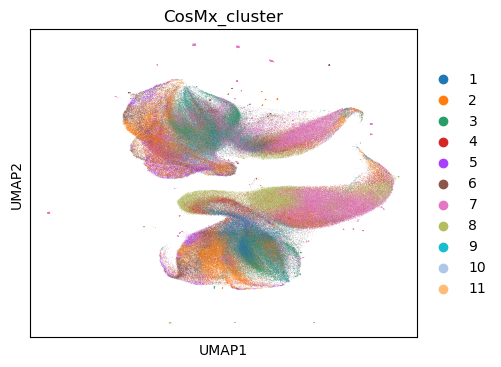

In [230]:
with rc_context({'figure.figsize':(5,4)}):
    sc.pl.umap(integrated_adata, color='CosMx_cluster', save='v3  by nanostring_cluster.png')

In [231]:
integrated_adata.write_h5ad(r'..\results\v3\nanostring_xenium_integrated.h5ad')

In [232]:
integrated_adata

AnnData object with n_obs × n_vars = 455516 × 100
    obs: 'sample', 'condition', 'experiment', 'CosMx_cluster'
    uns: 'neighbors', 'umap', 'tsne', 'sample_colors', 'experiment_colors', 'condition_colors', 'CosMx_cluster_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    obsp: 'distances', 'connectivities'

# cluster marker gene in xenium

In [133]:
xenium_corrected = sc.read_h5ad(r'..\..\20240718_xenium\catalyst_release_AC_EU_Jul18\corrected.h5ad')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\anndata\_core\anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [135]:
xenium_sub_adata = integrated_adata[integrated_adata.obs['experiment'] == 'Xenium']

In [137]:
xenium_corrected.obs['cluster'] = xenium_sub_adata.obs['nanostring_cluster']
xenium_corrected.obs['cell'] = xenium_sub_adata.obs_names

In [138]:
sc.tl.rank_genes_groups(xenium_corrected, 'cluster')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encounter

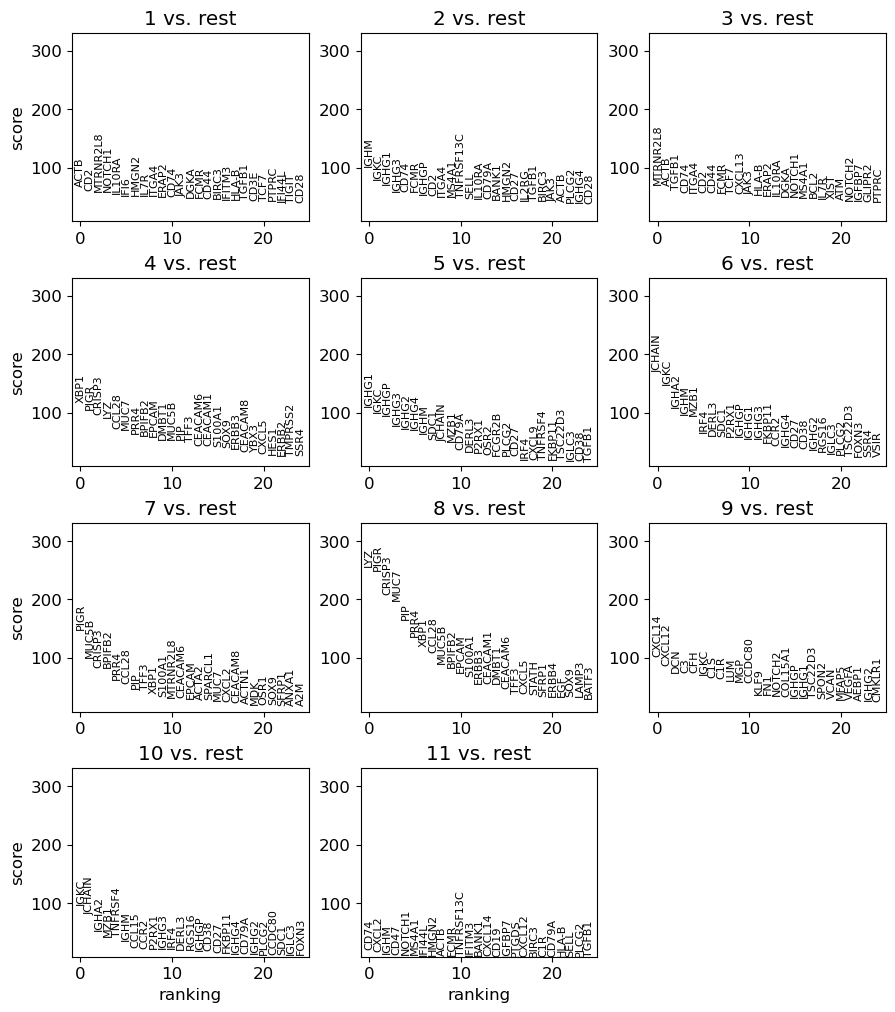

In [ ]:
with rc_context({'font.size': 12, 'figure.figsize':(3.5,3)}):
    sc.pl.rank_genes_groups(xenium_corrected, n_genes=25, ncols=3, save=' xenium by cluster.png')

In [205]:
xenium_corrected.write_h5ad(r'..\results\xenium_corrected.h5ad')

# Clustering of cluster 9 cells

In [139]:
xenium_corrected_df = pd.DataFrame(xenium_corrected.X, columns=xenium_corrected.var_names)
xenium_corrected_df['cell'] = xenium_corrected.obs['cell'].tolist()

In [140]:
cluster_9_adata = integrated_adata[integrated_adata.obs['nanostring_cluster'] == '9']

In [141]:
cluster_9_adata

View of AnnData object with n_obs × n_vars = 12173 × 100
    obs: 'sample', 'condition', 'experiment', 'nanostring_cluster', 'CoxMx_cluster', 'CosMx_cluster'
    uns: 'neighbors', 'umap', 'tsne', 'sample_colors', 'experiment_colors', 'condition_colors', 'nanostring_cluster_colors', 'CosMx_cluster_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    obsp: 'distances', 'connectivities'

In [142]:
sc.pp.neighbors(cluster_9_adata, n_neighbors=10)

In [144]:
sc.tl.umap(cluster_9_adata)
sc.tl.tsne(cluster_9_adata)

In [145]:
sc.tl.leiden(cluster_9_adata, resolution=0.3)

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


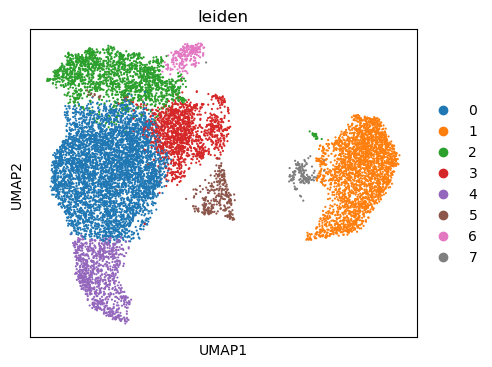

In [146]:
with rc_context({'figure.figsize':(5,4)}):
    sc.pl.umap(cluster_9_adata, color='leiden', save=' v2 integrated cluster 9 by leiden.png')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


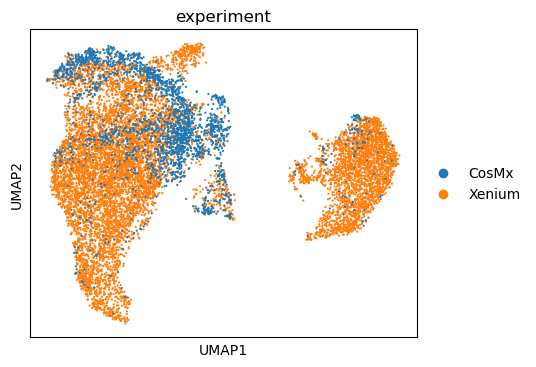

In [147]:
with rc_context({'figure.figsize':(5,4)}):
    sc.pl.umap(cluster_9_adata, color='experiment', save=' v2 integrated cluster 9 by experiment.png')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


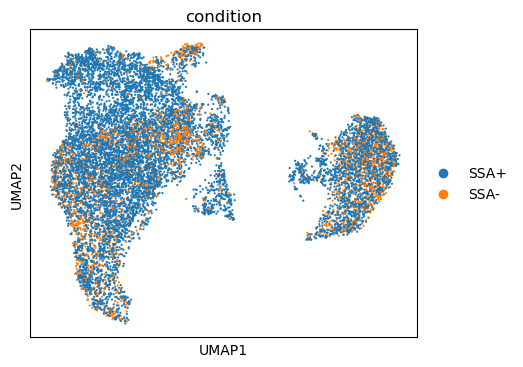

In [148]:
with rc_context({'figure.figsize':(5,4)}):
    sc.pl.umap(cluster_9_adata, color='condition', save=' v2integrated cluster 9 by condition.png')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


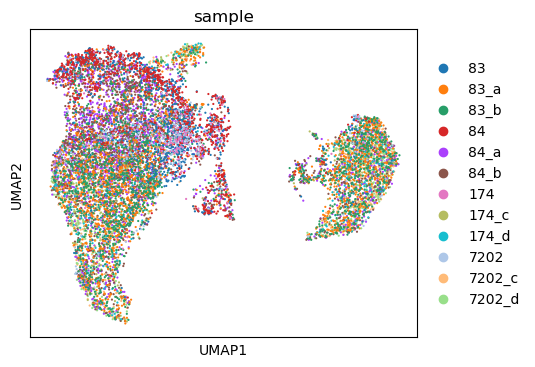

In [149]:
with rc_context({'figure.figsize':(5,4)}):
    sc.pl.umap(cluster_9_adata, color='sample', save=' v2 integrated cluster 9 by sample.png')

In [150]:
cluster_9_adata.write_h5ad(r'..\results\v2\cluster_9_integrated.h5ad')

In [151]:
cluster_9_adata.obs_names

Index(['abjlffpi-1', 'achnbnda-1', 'acifcgmc-1', 'adonfhha-1', 'aekacijj-1',
       'aeniglnb-1', 'aofgdmod-1', 'aplflled-1', 'bbjkljlo-1', 'bdgifhbe-1',
       ...
       'rerun2_c_1_29_325', 'rerun2_c_1_29_339', 'rerun2_c_1_29_343',
       'rerun2_c_1_29_359', 'rerun2_c_1_29_368', 'rerun2_c_1_29_472',
       'rerun2_c_1_30_93', 'rerun2_c_1_30_155', 'rerun2_c_1_30_183',
       'rerun2_c_1_33_134'],
      dtype='object', length=12173)

## Assign cluster label to xenium and nanostring data

### xenium

In [295]:
xenium_cluster_9 = cluster_9_adata[cluster_9_adata.obs['experiment'] == 'xenium']
xenium_cluster_9_labels = pd.DataFrame({'cell': xenium_cluster_9.obs_names, 'leiden': xenium_cluster_9.obs['leiden'].tolist()})
xenium_cluster_9_labels['X_umap1'] = xenium_cluster_9.obsm['X_umap'][:,0]
xenium_cluster_9_labels['X_umap2'] = xenium_cluster_9.obsm['X_umap'][:,1]

xenium_cluster_9_labels['X_tsne1'] = xenium_cluster_9.obsm['X_tsne'][:,0]
xenium_cluster_9_labels['X_tsne2'] = xenium_cluster_9.obsm['X_tsne'][:,1]

In [296]:
xenium_cluster_9_expression = xenium_corrected[xenium_corrected.obs['cluster'] == '9']
xenium_cell_order = xenium_cluster_9_expresion.obs['cell'].tolist()

xenium_cluster_9_labels['cell'] = pd.Categorical(xenium_cell_order, categories=xenium_cell_order)
xenium_cluster_9_labels = xenium_cluster_9_labels.sort_values('cell')

xenium_cluster_9_expression.obs['leiden'] = xenium_cluster_9_labels['leiden'].tolist()
xenium_cluster_9_expression.obsm['X_umap'] = xenium_cluster_9_labels[['X_umap1', 'X_umap2']].values
xenium_cluster_9_expression.obsm['X_tsne'] = xenium_cluster_9_labels[['X_tsne1', 'X_tsne2']].values

C:\Users\zfang38\AppData\Local\Temp\ipykernel_24544\2885849443.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  xenium_cluster_9_expression.obs['leiden'] = xenium_cluster_9_labels['leiden'].tolist()


In [297]:
xenium_cluster_9_expression.uns['leiden_colors'] = cluster_9_adata.uns['leiden_colors']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


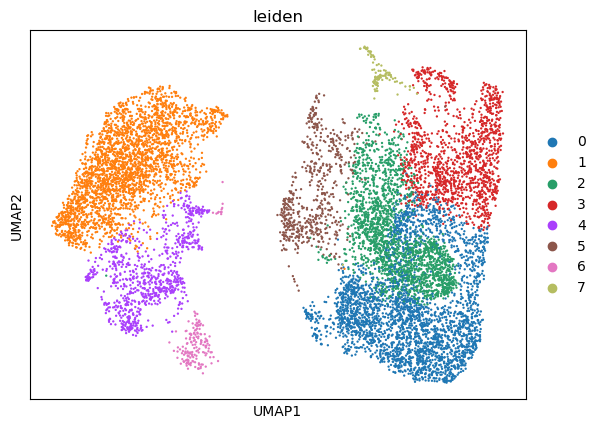

In [298]:
sc.pl.umap(xenium_cluster_9_expression, color='leiden')

In [299]:
sc.tl.rank_genes_groups(xenium_cluster_9_expression, 'leiden')

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\tools\_rank_genes_groups.py:422: RuntimeWarning: invalid value encounter

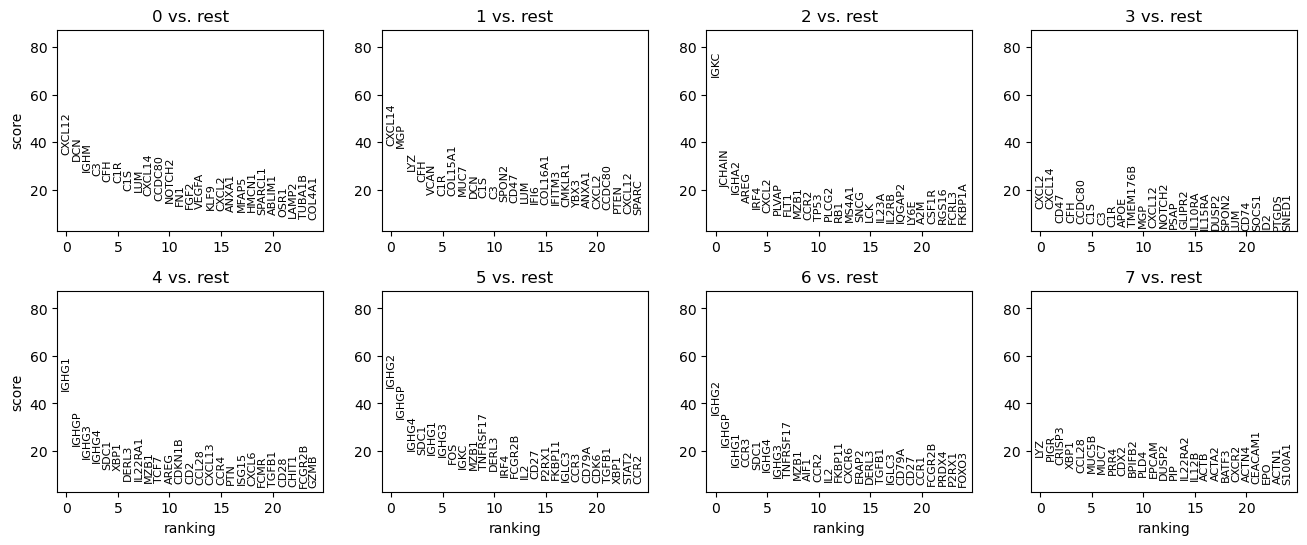

In [300]:
with rc_context({'figure.figsize':(4,3)}):
    sc.pl.rank_genes_groups(xenium_cluster_9_expression, n_genes=25, ncols=4, save=' xenium cluster 9 by leiden.png')

In [364]:
xenium_cluster_9_expresion.write(r'..\results\xenium_cluster_9_expression.h5ad')

In [365]:
xenium_cluster_9_expression.obs.to_csv(r'..\results\xenium_cluster_9_expression_obs.csv')

In [368]:
with open(r'..\results\xemiun_cluster_9_expression_obsm.pkl', 'wb') as f:
    pickle.dump({'X_umap': xenium_cluster_9_expression.obsm['X_umap'], 'X_tsne': xenium_cluster_9_expression.obsm['X_tsne']}, f)

In [371]:
with open(r'..\results\xenium_cluster_9_expression_uns.pkl', 'wb') as f:
    pickle.dump(xenium_cluster_9_expression.uns, f)

### nanostring

In [336]:
nanostring_cluster_9 = cluster_9_adata[cluster_9_adata.obs['experiment'] == 'nanostring']
nanostring_cluster_9_labels = pd.DataFrame({'cell': nanostring_cluster_9.obs_names, 'leiden': nanostring_cluster_9.obs['leiden'].tolist()})
nanostring_cluster_9_labels['X_umap1'] = nanostring_cluster_9.obsm['X_umap'][:,0]
nanostring_cluster_9_labels['X_umap2'] = nanostring_cluster_9.obsm['X_umap'][:,1]

nanostring_cluster_9_labels['X_tsne1'] = nanostring_cluster_9.obsm['X_tsne'][:,0]
nanostring_cluster_9_labels['X_tsne2'] = nanostring_cluster_9.obsm['X_tsne'][:,1]

In [337]:
# Extract nanostring cluster 9 expression
nanostring_expression_df = pd.DataFrame(np.concatenate(nanostring_data, axis=0), columns=nanostring_genes[0])
nanostring_expression_df.astype('float')
nanostring_expression_df['cell'] = nanostring_cells
nanostring_integrated = integrated_adata[integrated_adata.obs['experiment'] == 'nanostring']

nanostring_labels = pd.DataFrame({'cell': nanostring_integrated.obs_names.tolist(),
                                  'cluster': nanostring_integrated.obs['nanostring_cluster'].tolist()})

# merge nanostring expression with nanostring labels
nanostring_expression_df = pd.merge(nanostring_expression_df, nanostring_labels, on='cell')

In [338]:
nanostring_cluster_9_expression_df = nanostring_expression_df[nanostring_expression_df['cluster'] == '9']
nanostring_cluster_9_expression_df = pd.merge(nanostring_cluster_9_expression_df, nanostring_cluster_9_labels, on='cell')

In [343]:
nanostring_cluster_9_expression = sc.AnnData(nanostring_cluster_9_expression_df.values[:,:1000].astype('float'))
nanostring_cluster_9_expression.obs_names = nanostring_cluster_9_expression_df['cell'].tolist()
nanostring_cluster_9_expression.var_names = nanostring_cluster_9_expression_df.columns[:1000]

nanostring_cluster_9_expression.obsm['X_umap'] = nanostring_cluster_9_expression_df[['X_umap1', 'X_umap2']].values
nanostring_cluster_9_expression.obsm['X_tsne'] = nanostring_cluster_9_expression_df[['X_tsne1', 'X_tsne2']].values
nanostring_cluster_9_expression.obs['leiden'] = nanostring_cluster_9_expression_df['leiden'].tolist()

nanostring_cluster_9_expression.uns['leiden_colors'] = cluster_9_adata.uns['leiden_colors']

c:\Users\zfang38\AppData\Local\anaconda3\envs\skim\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


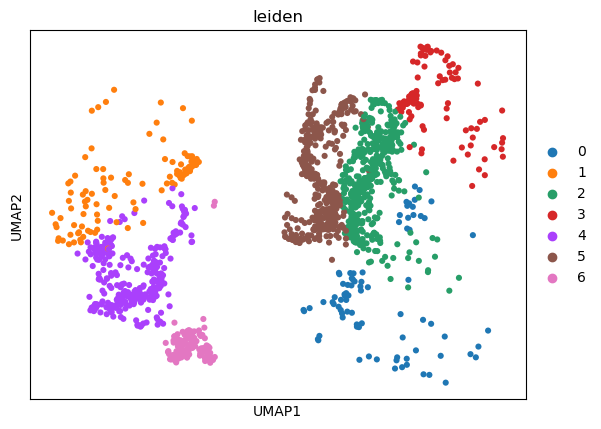

In [344]:
sc.pl.umap(nanostring_cluster_9_expression, color='leiden', save=' nanostring cluster 9 by leiden.png')

In [345]:
sc.tl.rank_genes_groups(nanostring_cluster_9_expression, 'leiden')

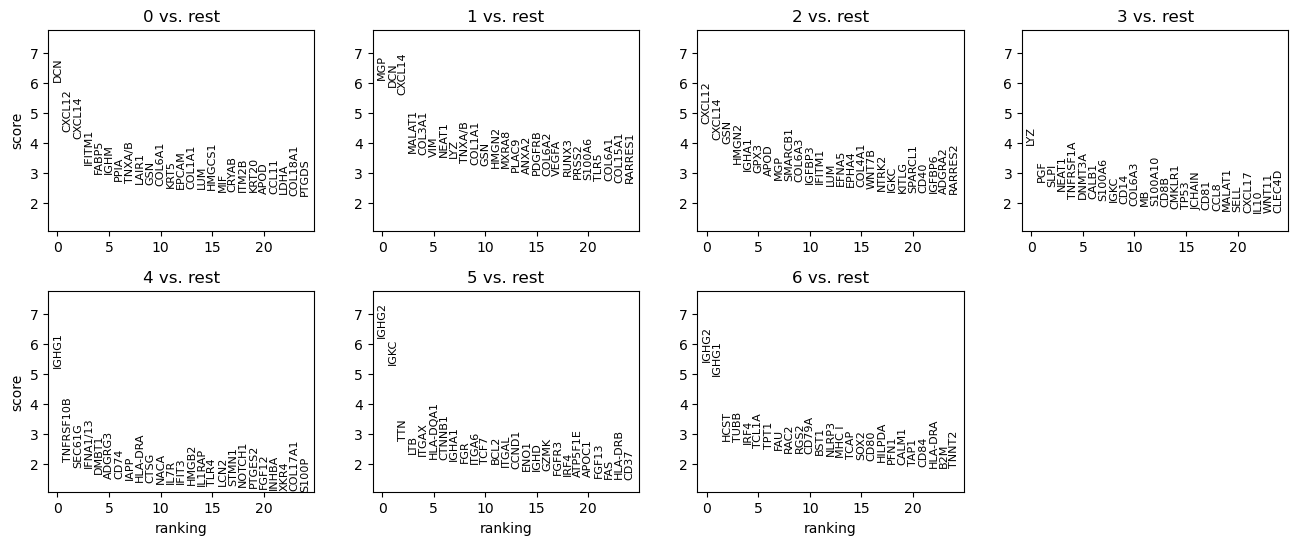

In [346]:
with rc_context({'figure.figsize':(4,3)}):
    sc.pl.rank_genes_groups(nanostring_cluster_9_expression, n_genes=25, ncols=4, save=' nanostring cluster 9 by leiden.png')

In [347]:
nanostring_cluster_9_expression.write_h5ad(r'..\results\nanostring_cluster_9_expression.h5ad')

In [361]:
nanostring_cluster_9_expression

AnnData object with n_obs × n_vars = 1542 × 1000
    obs: 'leiden'
    uns: 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_umap', 'X_tsne'